In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

GENERATED_DIR = Path.cwd() / "generated"

In [2]:
ACOUSTIC_DIR = GENERATED_DIR / "acoustic"
LINGUISTIC_DIR = GENERATED_DIR / "linguistic_frame"

In [3]:
DATA_SIZE = 10 # TODO: remove; just for prototyping

acoustic_paths = sorted(ACOUSTIC_DIR.glob("*"))[:DATA_SIZE] # Remove mean.npy and std.npy
linguistic_paths = sorted(LINGUISTIC_DIR.glob("*"))[:DATA_SIZE]
len(acoustic_paths), len(linguistic_paths)

(10, 10)

In [4]:
acoustic_arrays = [np.load(path) for path in acoustic_paths]
linguistic_arrays = [np.load(path) for path in linguistic_paths]

In [22]:
# Truncate, same length
acoustic_arrays = [ac_arr[:len(ln_arr)] for ac_arr, ln_arr in zip(acoustic_arrays, linguistic_arrays)]

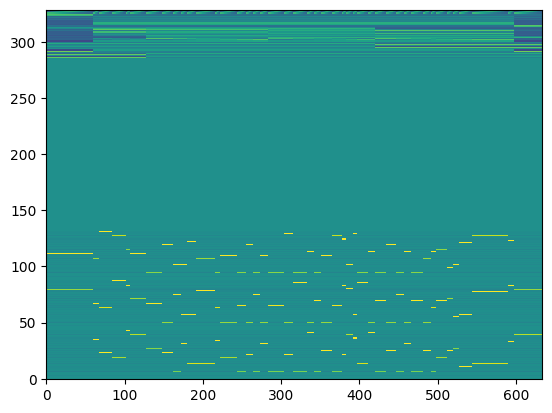

In [23]:
plt.imshow(linguistic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [24]:
linguistic_arrays[0].shape

(634, 329)

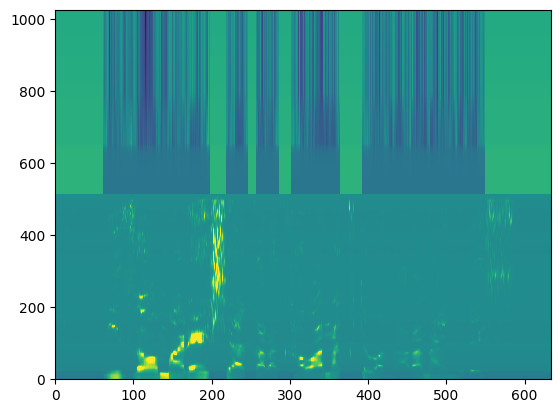

In [25]:
plt.imshow(acoustic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [26]:
f0_arrays = [arr[:, 0:0 + 1] for arr in acoustic_arrays]
sp_arrays = [arr[:, 1:1 + 513] for arr in acoustic_arrays]
ap_arrays = [arr[:, 1 + 513: 1 + 513 + 513] for arr in acoustic_arrays]

In [27]:
dataset = tf.data.Dataset.from_tensor_slices(
    (
        np.concatenate(linguistic_arrays, axis=0),
        (
            np.concatenate(f0_arrays, axis=0),
            np.concatenate(sp_arrays, axis=0),
            np.concatenate(ap_arrays, axis=0),
        )
    )
).shuffle(2048).batch(1024)

In [109]:
def get_model(input_dim = 329, f0_dim=1, sp_dim=513, ap_dim=513):
    ipt = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(256,)(ipt)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dense(128,)(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dense(64,)(x)
    x = tf.keras.layers.ReLU()(x)
    f0_out = tf.keras.layers.Dense(f0_dim)(x)
    
    x = tf.keras.layers.Reshape((1, 64))(x)

    sp_mid = tf.keras.layers.Conv1DTranspose(32, 7, strides=4, padding='same')(x)
    sp_mid = tf.keras.layers.ReLU()(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(16, 7, strides=4, padding='same')(sp_mid)
    sp_mid = tf.keras.layers.ReLU()(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(8, 7, strides=4, padding='same')(sp_mid)
    sp_mid = tf.keras.layers.ReLU()(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(4, 7, strides=4, padding='same')(sp_mid)
    sp_mid = tf.keras.layers.ReLU()(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(2, 7, strides=2, padding='same')(sp_mid)
    sp_mid = tf.keras.layers.Conv1DTranspose(1, 2, strides=1, padding='valid')(sp_mid)
    sp_out = tf.keras.layers.Flatten()(sp_mid)

    ap_mid = tf.keras.layers.Conv1DTranspose(32, 7, strides=4, padding='same')(x)
    ap_mid = tf.keras.layers.ReLU()(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(16, 7, strides=4, padding='same')(ap_mid)
    ap_mid = tf.keras.layers.ReLU()(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(8, 7, strides=4, padding='same')(ap_mid)
    ap_mid = tf.keras.layers.ReLU()(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(4, 7, strides=4, padding='same')(ap_mid)
    ap_mid = tf.keras.layers.ReLU()(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(2, 7, strides=2, padding='same')(ap_mid)
    ap_mid = tf.keras.layers.Conv1DTranspose(1, 2, strides=1, padding='valid')(ap_mid)
    ap_out = tf.keras.layers.Flatten()(ap_mid)

    model = tf.keras.models.Model(inputs=ipt, outputs=(f0_out, sp_out, ap_out))
    return model

model = get_model()
model.summary()

Model: "model_19"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_23 (InputLayer)          [(None, 329)]        0           []                               
                                                                                                  
 dense_121 (Dense)              (None, 256)          84480       ['input_23[0][0]']               
                                                                                                  
 re_lu_102 (ReLU)               (None, 256)          0           ['dense_121[0][0]']              
                                                                                                  
 dense_122 (Dense)              (None, 128)          32896       ['re_lu_102[0][0]']              
                                                                                           

In [110]:
from tensorflow.keras.losses import MeanSquaredError as MSE

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=(MSE(), MSE(), MSE()),
              metrics=['MAE'])

In [163]:
model.fit(dataset, epochs=100)

Epoch 1/100
8/8 [==============================] - 0s 29ms/step - loss: 0.6017 - dense_124_loss: 0.0368 - flatten_loss: 0.4871 - flatten_1_loss: 0.0777 - dense_124_MAE: 0.1066 - flatten_MAE: 0.1473 - flatten_1_MAE: 0.1513
Epoch 2/100
8/8 [==============================] - 0s 28ms/step - loss: 0.6093 - dense_124_loss: 0.0394 - flatten_loss: 0.4916 - flatten_1_loss: 0.0783 - dense_124_MAE: 0.1048 - flatten_MAE: 0.1455 - flatten_1_MAE: 0.1517
Epoch 3/100
8/8 [==============================] - 0s 29ms/step - loss: 0.6600 - dense_124_loss: 0.0557 - flatten_loss: 0.5217 - flatten_1_loss: 0.0825 - dense_124_MAE: 0.1348 - flatten_MAE: 0.1506 - flatten_1_MAE: 0.1554
Epoch 4/100
8/8 [==============================] - 0s 29ms/step - loss: 0.6439 - dense_124_loss: 0.0474 - flatten_loss: 0.5169 - flatten_1_loss: 0.0796 - dense_124_MAE: 0.1325 - flatten_MAE: 0.1595 - flatten_1_MAE: 0.1574
Epoch 5/100
8/8 [==============================] - 0s 30ms/step - loss: 0.6382 - dense_124_loss: 0.0379 - flatte

8/8 [==============================] - 0s 28ms/step - loss: 0.5864 - dense_124_loss: 0.0323 - flatten_loss: 0.4727 - flatten_1_loss: 0.0813 - dense_124_MAE: 0.0954 - flatten_MAE: 0.1463 - flatten_1_MAE: 0.1575
Epoch 38/100
8/8 [==============================] - 0s 28ms/step - loss: 0.5998 - dense_124_loss: 0.0252 - flatten_loss: 0.4999 - flatten_1_loss: 0.0748 - dense_124_MAE: 0.0947 - flatten_MAE: 0.1470 - flatten_1_MAE: 0.1480
Epoch 39/100
8/8 [==============================] - 0s 27ms/step - loss: 0.5935 - dense_124_loss: 0.0492 - flatten_loss: 0.4705 - flatten_1_loss: 0.0738 - dense_124_MAE: 0.1322 - flatten_MAE: 0.1486 - flatten_1_MAE: 0.1649
Epoch 40/100
8/8 [==============================] - 0s 28ms/step - loss: 0.5680 - dense_124_loss: 0.0454 - flatten_loss: 0.4497 - flatten_1_loss: 0.0729 - dense_124_MAE: 0.1259 - flatten_MAE: 0.1430 - flatten_1_MAE: 0.1548
Epoch 41/100
8/8 [==============================] - 0s 27ms/step - loss: 0.5429 - dense_124_loss: 0.0418 - flatten_loss: 

8/8 [==============================] - 0s 30ms/step - loss: 0.5544 - dense_124_loss: 0.0260 - flatten_loss: 0.4610 - flatten_1_loss: 0.0674 - dense_124_MAE: 0.1008 - flatten_MAE: 0.1422 - flatten_1_MAE: 0.1530
Epoch 74/100
8/8 [==============================] - 0s 28ms/step - loss: 0.5796 - dense_124_loss: 0.0265 - flatten_loss: 0.4894 - flatten_1_loss: 0.0637 - dense_124_MAE: 0.0971 - flatten_MAE: 0.1420 - flatten_1_MAE: 0.1415
Epoch 75/100
8/8 [==============================] - 0s 29ms/step - loss: 0.6166 - dense_124_loss: 0.0262 - flatten_loss: 0.5180 - flatten_1_loss: 0.0723 - dense_124_MAE: 0.0934 - flatten_MAE: 0.1554 - flatten_1_MAE: 0.1514
Epoch 76/100
8/8 [==============================] - 0s 29ms/step - loss: 0.5656 - dense_124_loss: 0.0306 - flatten_loss: 0.4619 - flatten_1_loss: 0.0732 - dense_124_MAE: 0.1040 - flatten_MAE: 0.1406 - flatten_1_MAE: 0.1468
Epoch 77/100
8/8 [==============================] - 0s 29ms/step - loss: 0.5501 - dense_124_loss: 0.0302 - flatten_loss: 

20/20 [==============================] - 0s 3ms/step


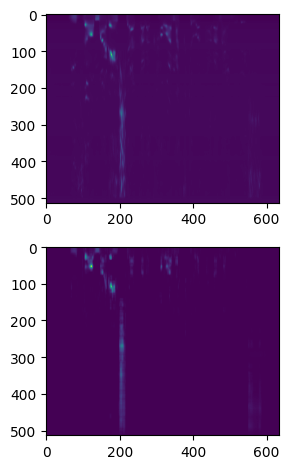

In [164]:
import librosa.display

idx = 0

fig, ax = plt.subplots(2, 1)
ax[0].imshow(sp_arrays[idx].T)
ax[1].imshow(model.predict(linguistic_arrays[idx])[1].T)

plt.tight_layout()

In [165]:
f0, sp, ap = model.predict(linguistic_arrays[idx])

20/20 [==============================] - 0s 3ms/step


In [166]:
mean = np.load("generated/acoustic/mean.npy")
std = np.load("generated/acoustic/std.npy")

def to_audio(f0, sp, ap):
    f0_mean, sp_mean, ap_mean = mean[0:1], mean[1:1+513], mean[1+513:]
    f0_std, sp_std, ap_std = std[0:1], std[1:1+513], std[1+513:]
    f0 = f0_mean + f0_std * f0
    sp = sp_mean + sp_std * sp
    ap = ap_mean + ap_std * ap
    audio = pw.synthesize(f0[:, 0].astype("double"), sp.astype("double"), ap.astype("double"), 22050)
    return audio

In [167]:
import pyworld as pw
import IPython

audio = to_audio(f0, sp, ap)
IPython.display.Audio(audio, rate=20050)

In [149]:
import pyworld as pw
import IPython

audio = to_audio(f0_arrays[idx], sp_arrays[idx], ap_arrays[idx])
IPython.display.Audio(audio, rate=20050)